In [242]:
import numpy as np
import matplotlib.pyplot as plt

%display plain

def without_diagonal(x):
    return x - diagonal_matrix(x.diagonal())

In [2]:
pi_aa, pi_cc, pi_gg, pi_tt, pi_ac, pi_ag, pi_at, pi_cg, pi_ct, pi_gt = var('pi_aa, pi_cc, pi_gg, pi_tt, pi_ac, pi_ag, pi_at, pi_cg, pi_ct, pi_gt')

pi10s = vector([pi_aa, pi_cc, pi_gg, pi_tt, pi_ac, pi_ag, pi_at, pi_cg, pi_ct, pi_gt])

for v in pi10s:
    assume(v,'real')
    assume(0 <= v)
    assume(v <= 1)


In [3]:
s = [0] + list(var([f"s_{i+1}" for i in range(45)]))

for v in s[1:]:
    assume(v,'real')
    assume(v >= 0)


# GTR10

In [4]:
q_gtr10 = np.full((10,10), x) * 0

# fmt: off
# @formatter:off    
q_gtr10[np.triu_indices(10)] = [
    0, s_1,  s_2,  s_3,  s_4,  s_5,  s_6,  s_7 ,  s_8, s_9,
         0, s_10, s_11, s_12, s_13, s_14, s_15, s_16, s_17,
               0, s_18, s_19, s_20, s_21, s_22, s_23, s_24,
                     0, s_25, s_26, s_27, s_28, s_29, s_30,
                           0, s_31, s_32, s_33, s_34, s_35,
                                 0, s_36, s_37, s_38, s_39,
                                       0, s_40, s_41, s_42, 
                                             0, s_43, s_44,
                                                   0, s_45,
                                                         0
]
# @formatter:on
# fmt: on
q_gtr10 = (q_gtr10 + q_gtr10.T) @ diagonal_matrix(pi10s)
q_gtr10 -= diagonal_matrix(np.sum(q_gtr10, axis=1))

In [5]:
-(pi10s @ q_gtr10.diagonal()).simplify_full()

2*pi_aa*pi_cc*s_1 + 2*pi_cc*pi_gg*s_10 + 2*pi_cc*pi_tt*s_11 + 2*pi_ac*pi_cc*s_12 + 2*pi_ag*pi_cc*s_13 + 2*pi_at*pi_cc*s_14 + 2*pi_cc*pi_cg*s_15 + 2*pi_cc*pi_ct*s_16 + 2*pi_cc*pi_gt*s_17 + 2*pi_gg*pi_tt*s_18 + 2*pi_ac*pi_gg*s_19 + 2*pi_aa*pi_gg*s_2 + 2*pi_ag*pi_gg*s_20 + 2*pi_at*pi_gg*s_21 + 2*pi_cg*pi_gg*s_22 + 2*pi_ct*pi_gg*s_23 + 2*pi_gg*pi_gt*s_24 + 2*pi_ac*pi_tt*s_25 + 2*pi_ag*pi_tt*s_26 + 2*pi_at*pi_tt*s_27 + 2*pi_cg*pi_tt*s_28 + 2*pi_ct*pi_tt*s_29 + 2*pi_aa*pi_tt*s_3 + 2*pi_gt*pi_tt*s_30 + 2*pi_ac*pi_ag*s_31 + 2*pi_ac*pi_at*s_32 + 2*pi_ac*pi_cg*s_33 + 2*pi_ac*pi_ct*s_34 + 2*pi_ac*pi_gt*s_35 + 2*pi_ag*pi_at*s_36 + 2*pi_ag*pi_cg*s_37 + 2*pi_ag*pi_ct*s_38 + 2*pi_ag*pi_gt*s_39 + 2*pi_aa*pi_ac*s_4 + 2*pi_at*pi_cg*s_40 + 2*pi_at*pi_ct*s_41 + 2*pi_at*pi_gt*s_42 + 2*pi_cg*pi_ct*s_43 + 2*pi_cg*pi_gt*s_44 + 2*pi_ct*pi_gt*s_45 + 2*pi_aa*pi_ag*s_5 + 2*pi_aa*pi_at*s_6 + 2*pi_aa*pi_cg*s_7 + 2*pi_aa*pi_ct*s_8 + 2*pi_aa*pi_gt*s_9

In [6]:
q_sym_gtr10 = np.diag(np.sqrt([p for p in pi10s])) @ q_gtr10 @ np.diag(np.sqrt([1/p for p in pi10s]))

In [7]:
np.all(q_sym_gtr10 - q_sym_gtr10.T == 0)

True

In [8]:
# q_sym_gtr10
q_sym_gtr10 = np.array([ [c.simplify_real() for c in row] for row in q_sym_gtr10])

#### code generation

In [9]:
print('np.'+repr(q_sym_gtr10).replace('sqrt','np.sqrt').replace(')*np.sqrt(','*').replace('object','np.float64'))

np.array([[-pi_cc*s_1 - pi_gg*s_2 - pi_tt*s_3 - pi_ac*s_4 - pi_ag*s_5 - pi_at*s_6 - pi_cg*s_7 - pi_ct*s_8 - pi_gt*s_9,
        np.sqrt(pi_aa*pi_cc)*s_1, np.sqrt(pi_aa*pi_gg)*s_2,
        np.sqrt(pi_aa*pi_tt)*s_3, np.sqrt(pi_aa*pi_ac)*s_4,
        np.sqrt(pi_aa*pi_ag)*s_5, np.sqrt(pi_aa*pi_at)*s_6,
        np.sqrt(pi_aa*pi_cg)*s_7, np.sqrt(pi_aa*pi_ct)*s_8,
        np.sqrt(pi_aa*pi_gt)*s_9],
       [np.sqrt(pi_aa*pi_cc)*s_1,
        -pi_aa*s_1 - pi_gg*s_10 - pi_tt*s_11 - pi_ac*s_12 - pi_ag*s_13 - pi_at*s_14 - pi_cg*s_15 - pi_ct*s_16 - pi_gt*s_17,
        np.sqrt(pi_cc*pi_gg)*s_10, np.sqrt(pi_cc*pi_tt)*s_11,
        np.sqrt(pi_ac*pi_cc)*s_12, np.sqrt(pi_ag*pi_cc)*s_13,
        np.sqrt(pi_at*pi_cc)*s_14, np.sqrt(pi_cc*pi_cg)*s_15,
        np.sqrt(pi_cc*pi_ct)*s_16, np.sqrt(pi_cc*pi_gt)*s_17],
       [np.sqrt(pi_aa*pi_gg)*s_2, np.sqrt(pi_cc*pi_gg)*s_10,
        -pi_cc*s_10 - pi_tt*s_18 - pi_ac*s_19 - pi_aa*s_2 - pi_ag*s_20 - pi_at*s_21 - pi_cg*s_22 - pi_ct*s_23 - pi_gt*s_24,
        np.sqr

# GTR10Z

In [10]:
q_gtr10z = np.full((10,10), x) * 0

# fmt: off
# @formatter:off
q_gtr10z[np.triu_indices(10)] = [
    0, 0, 0, 0, s_1,  s_2,  s_3,    0,    0,    0,
       0, 0, 0, s_4,    0,    0,  s_5,  s_6,    0,
          0, 0,   0,  s_7,    0,  s_8,    0,  s_9,
             0,   0,    0, s_10,    0, s_11, s_12,
                  0, s_13, s_14, s_15, s_16,    0,
                        0, s_17, s_18,    0, s_19,
                              0,    0, s_20, s_21, 
                                    0, s_22, s_23,
                                          0, s_24,
                                                0
]
# @formatter:on
# fmt: on
q_gtr10z = (q_gtr10z + q_gtr10z.T) @ diagonal_matrix(pi10s)
q_gtr10z -= diagonal_matrix(np.sum(q_gtr10z, axis=1))

In [11]:
-(pi10s @ q_gtr10z.diagonal()).simplify_full()

2*pi_aa*pi_ac*s_1 + 2*pi_at*pi_tt*s_10 + 2*pi_ct*pi_tt*s_11 + 2*pi_gt*pi_tt*s_12 + 2*pi_ac*pi_ag*s_13 + 2*pi_ac*pi_at*s_14 + 2*pi_ac*pi_cg*s_15 + 2*pi_ac*pi_ct*s_16 + 2*pi_ag*pi_at*s_17 + 2*pi_ag*pi_cg*s_18 + 2*pi_ag*pi_gt*s_19 + 2*pi_aa*pi_ag*s_2 + 2*pi_at*pi_ct*s_20 + 2*pi_at*pi_gt*s_21 + 2*pi_cg*pi_ct*s_22 + 2*pi_cg*pi_gt*s_23 + 2*pi_ct*pi_gt*s_24 + 2*pi_aa*pi_at*s_3 + 2*pi_ac*pi_cc*s_4 + 2*pi_cc*pi_cg*s_5 + 2*pi_cc*pi_ct*s_6 + 2*pi_ag*pi_gg*s_7 + 2*pi_cg*pi_gg*s_8 + 2*pi_gg*pi_gt*s_9

In [12]:
matrix(without_diagonal(q_gtr10z))

[         0          0          0          0  pi_ac*s_1  pi_ag*s_2  pi_at*s_3          0          0          0]
[         0          0          0          0  pi_ac*s_4          0          0  pi_cg*s_5  pi_ct*s_6          0]
[         0          0          0          0          0  pi_ag*s_7          0  pi_cg*s_8          0  pi_gt*s_9]
[         0          0          0          0          0          0 pi_at*s_10          0 pi_ct*s_11 pi_gt*s_12]
[ pi_aa*s_1  pi_cc*s_4          0          0          0 pi_ag*s_13 pi_at*s_14 pi_cg*s_15 pi_ct*s_16          0]
[ pi_aa*s_2          0  pi_gg*s_7          0 pi_ac*s_13          0 pi_at*s_17 pi_cg*s_18          0 pi_gt*s_19]
[ pi_aa*s_3          0          0 pi_tt*s_10 pi_ac*s_14 pi_ag*s_17          0          0 pi_ct*s_20 pi_gt*s_21]
[         0  pi_cc*s_5  pi_gg*s_8          0 pi_ac*s_15 pi_ag*s_18          0          0 pi_ct*s_22 pi_gt*s_23]
[         0  pi_cc*s_6          0 pi_tt*s_11 pi_ac*s_16          0 pi_at*s_20 pi_cg*s_22          0 pi_g

In [13]:
q_sym_gtr10z = np.diag(np.sqrt([p for p in pi10s])) @ q_gtr10z @ np.diag(np.sqrt([1/p for p in pi10s]))

In [14]:
np.all(q_sym_gtr10z - q_sym_gtr10z.T == 0)

True

In [15]:
# q_sym_gtr10z
q_sym_gtr10z = np.array([ [c.simplify_real() for c in row] for row in q_sym_gtr10z])

#### code generation

In [16]:
print('np.'+repr(q_sym_gtr10z).replace('sqrt','np.sqrt').replace(')*np.sqrt(','*').replace('object','np.float64'))

np.array([[-pi_ac*s_1 - pi_ag*s_2 - pi_at*s_3, 0, 0, 0,
        np.sqrt(pi_aa*pi_ac)*s_1, np.sqrt(pi_aa*pi_ag)*s_2,
        np.sqrt(pi_aa*pi_at)*s_3, 0, 0, 0],
       [0, -pi_ac*s_4 - pi_cg*s_5 - pi_ct*s_6, 0, 0,
        np.sqrt(pi_ac*pi_cc)*s_4, 0, 0, np.sqrt(pi_cc*pi_cg)*s_5,
        np.sqrt(pi_cc*pi_ct)*s_6, 0],
       [0, 0, -pi_ag*s_7 - pi_cg*s_8 - pi_gt*s_9, 0, 0,
        np.sqrt(pi_ag*pi_gg)*s_7, 0, np.sqrt(pi_cg*pi_gg)*s_8, 0,
        np.sqrt(pi_gg*pi_gt)*s_9],
       [0, 0, 0, -pi_at*s_10 - pi_ct*s_11 - pi_gt*s_12, 0, 0,
        np.sqrt(pi_at*pi_tt)*s_10, 0, np.sqrt(pi_ct*pi_tt)*s_11,
        np.sqrt(pi_gt*pi_tt)*s_12],
       [np.sqrt(pi_aa*pi_ac)*s_1, np.sqrt(pi_ac*pi_cc)*s_4, 0, 0,
        -pi_aa*s_1 - pi_ag*s_13 - pi_at*s_14 - pi_cg*s_15 - pi_ct*s_16 - pi_cc*s_4,
        np.sqrt(pi_ac*pi_ag)*s_13, np.sqrt(pi_ac*pi_at)*s_14,
        np.sqrt(pi_ac*pi_cg)*s_15, np.sqrt(pi_ac*pi_ct)*s_16, 0],
       [np.sqrt(pi_aa*pi_ag)*s_2, 0, np.sqrt(pi_ag*pi_gg)*s_7, 0,
        np.sqrt(pi_

# Cellphy10

In [17]:
q_cp10 = np.full((10,10), x) * 0

# fmt: off
# @formatter:off
q_cp10[np.triu_indices(10)] = [
    0, 0, 0, 0, s_1, s_2, s_3,   0,   0,   0,
       0, 0, 0, s_1,   0,   0, s_4, s_5,   0,
          0, 0,   0, s_2,   0, s_4,   0, s_6,
             0,   0,   0, s_3,   0, s_5, s_6,
                  0, s_4, s_5, s_2, s_3,   0,
                       0, s_6, s_1,   0, s_3,
                            0,   0, s_1, s_2, 
                                 0, s_6, s_5,
                                      0, s_4,
                                           0]
# @formatter:on
# fmt: on

q_cp10 = (q_cp10 + q_cp10.T) @ diagonal_matrix(pi10s)
q_cp10 -= diagonal_matrix(np.sum(q_cp10, axis=1))

In [18]:
-(pi10s @ q_cp10.diagonal()/2).simplify_full()

(pi_aa*pi_ac + pi_ac*pi_cc + pi_ag*pi_cg + pi_at*pi_ct)*s_1 + (pi_aa*pi_ag + pi_ac*pi_cg + pi_ag*pi_gg + pi_at*pi_gt)*s_2 + (pi_aa*pi_at + pi_ac*pi_ct + pi_ag*pi_gt + pi_at*pi_tt)*s_3 + (pi_ac*pi_ag + pi_cc*pi_cg + pi_cg*pi_gg + pi_ct*pi_gt)*s_4 + (pi_ac*pi_at + pi_cc*pi_ct + pi_cg*pi_gt + pi_ct*pi_tt)*s_5 + (pi_ag*pi_at + pi_cg*pi_ct + pi_gg*pi_gt + pi_gt*pi_tt)*s_6

In [19]:
matrix(without_diagonal(q_cp10))

[        0         0         0         0 pi_ac*s_1 pi_ag*s_2 pi_at*s_3         0         0         0]
[        0         0         0         0 pi_ac*s_1         0         0 pi_cg*s_4 pi_ct*s_5         0]
[        0         0         0         0         0 pi_ag*s_2         0 pi_cg*s_4         0 pi_gt*s_6]
[        0         0         0         0         0         0 pi_at*s_3         0 pi_ct*s_5 pi_gt*s_6]
[pi_aa*s_1 pi_cc*s_1         0         0         0 pi_ag*s_4 pi_at*s_5 pi_cg*s_2 pi_ct*s_3         0]
[pi_aa*s_2         0 pi_gg*s_2         0 pi_ac*s_4         0 pi_at*s_6 pi_cg*s_1         0 pi_gt*s_3]
[pi_aa*s_3         0         0 pi_tt*s_3 pi_ac*s_5 pi_ag*s_6         0         0 pi_ct*s_1 pi_gt*s_2]
[        0 pi_cc*s_4 pi_gg*s_4         0 pi_ac*s_2 pi_ag*s_1         0         0 pi_ct*s_6 pi_gt*s_5]
[        0 pi_cc*s_5         0 pi_tt*s_5 pi_ac*s_3         0 pi_at*s_1 pi_cg*s_6         0 pi_gt*s_4]
[        0         0 pi_gg*s_6 pi_tt*s_6         0 pi_ag*s_3 pi_at*s_2 pi_cg*s_5 p

In [20]:
q_sym_cp10 = np.diag(np.sqrt([p for p in pi10s])) @ q_cp10 @ np.diag(np.sqrt([1/p for p in pi10s]))

In [21]:
np.all(q_sym_cp10 - q_sym_cp10.T == 0)

True

In [22]:
# q_sym_cp10
q_sym_cp10 = np.array([ [c.simplify_real() for c in row] for row in q_sym_cp10])

#### code generation

In [23]:
print('np.'+repr(q_sym_cp10).replace('sqrt','np.sqrt').replace(')*np.sqrt(','*').replace('object','np.float64'))

np.array([[-pi_ac*s_1 - pi_ag*s_2 - pi_at*s_3, 0, 0, 0,
        np.sqrt(pi_aa*pi_ac)*s_1, np.sqrt(pi_aa*pi_ag)*s_2,
        np.sqrt(pi_aa*pi_at)*s_3, 0, 0, 0],
       [0, -pi_ac*s_1 - pi_cg*s_4 - pi_ct*s_5, 0, 0,
        np.sqrt(pi_ac*pi_cc)*s_1, 0, 0, np.sqrt(pi_cc*pi_cg)*s_4,
        np.sqrt(pi_cc*pi_ct)*s_5, 0],
       [0, 0, -pi_ag*s_2 - pi_cg*s_4 - pi_gt*s_6, 0, 0,
        np.sqrt(pi_ag*pi_gg)*s_2, 0, np.sqrt(pi_cg*pi_gg)*s_4, 0,
        np.sqrt(pi_gg*pi_gt)*s_6],
       [0, 0, 0, -pi_at*s_3 - pi_ct*s_5 - pi_gt*s_6, 0, 0,
        np.sqrt(pi_at*pi_tt)*s_3, 0, np.sqrt(pi_ct*pi_tt)*s_5,
        np.sqrt(pi_gt*pi_tt)*s_6],
       [np.sqrt(pi_aa*pi_ac)*s_1, np.sqrt(pi_ac*pi_cc)*s_1, 0, 0,
        -pi_aa*s_1 - pi_cc*s_1 - pi_cg*s_2 - pi_ct*s_3 - pi_ag*s_4 - pi_at*s_5,
        np.sqrt(pi_ac*pi_ag)*s_4, np.sqrt(pi_ac*pi_at)*s_5,
        np.sqrt(pi_ac*pi_cg)*s_2, np.sqrt(pi_ac*pi_ct)*s_3, 0],
       [np.sqrt(pi_aa*pi_ag)*s_2, 0, np.sqrt(pi_ag*pi_gg)*s_2, 0,
        np.sqrt(pi_ac*pi_ag)*s_4,

## find the GTR10Z model that matches the cellphy model

first, match the equilibirum vectors, then solve for the s_i's

In [24]:
scps = var([f'sc_{i}' for i in range(7)])

q_cp10_alt = matrix(q_cp10)({s[idx]: scps[idx] for idx in range(1,7)})

In [25]:
soln = solve([expr==0 for expr in list((q_gtr10z - q_cp10_alt).reshape(-1)) if not (expr == 0)], s[1:25])

In [26]:
soln

[[s_1 == sc_1,
  s_2 == sc_2,
  s_3 == sc_3,
  s_4 == sc_1,
  s_5 == sc_4,
  s_6 == sc_5,
  s_7 == sc_2,
  s_8 == sc_4,
  s_9 == sc_6,
  s_10 == sc_3,
  s_11 == sc_5,
  s_12 == sc_6,
  s_13 == sc_4,
  s_14 == sc_5,
  s_15 == sc_2,
  s_16 == sc_3,
  s_17 == sc_6,
  s_18 == sc_1,
  s_19 == sc_3,
  s_20 == sc_1,
  s_21 == sc_2,
  s_22 == sc_6,
  s_23 == sc_5,
  s_24 == sc_4]]

In [27]:
[ t.rhs() for t in soln[0]]

[sc_1,
 sc_2,
 sc_3,
 sc_1,
 sc_4,
 sc_5,
 sc_2,
 sc_4,
 sc_6,
 sc_3,
 sc_5,
 sc_6,
 sc_4,
 sc_5,
 sc_2,
 sc_3,
 sc_6,
 sc_1,
 sc_3,
 sc_1,
 sc_2,
 sc_6,
 sc_5,
 sc_4]

# GTR4

In [28]:
pi_a, pi_c, pi_g, pi_t = var('pi_a, pi_c, pi_g, pi_t')
pi4s = vector([pi_a, pi_c, pi_g, pi_t])

for v in pi4s:
    assume(v,'real')
    assume(0 <= v)
    assume(v <= 1)

pi16_4s = vector(np.kron(pi4s,pi4s))

s_ac, s_ag, s_at, s_cg, s_ct, s_gt = var('s_ac, s_ag, s_at, s_cg, s_ct, s_gt')
s4s = vector([s_ac, s_ag, s_at, s_cg, s_ct, s_gt])

for v in s4s:
    assume(v,'real')
    assume(0 <= v)


In [29]:
q_gtr4 = np.full((4,4), x) * 0

# fmt: off
# @formatter:off
q_gtr4[np.triu_indices(4)] = [
    0, s_ac, s_ag, s_at, 
          0, s_cg, s_ct,
                0, s_gt,
                      0]
# @formatter:on
# fmt: on

q_gtr4 = (q_gtr4 + q_gtr4.T) @ diagonal_matrix(pi4s)
q_gtr4 -= diagonal_matrix(np.sum(q_gtr4, axis=1))

In [30]:
q_sym_gtr4 = np.diag([sqrt(p) for p in pi4s]) @ q_gtr4 @ np.diag([sqrt(1/p) for p in pi4s])

In [31]:
without_diagonal(matrix(q_sym_gtr4))

[                         0 sqrt(pi_a)*sqrt(pi_c)*s_ac sqrt(pi_a)*sqrt(pi_g)*s_ag sqrt(pi_a)*sqrt(pi_t)*s_at]
[sqrt(pi_a)*sqrt(pi_c)*s_ac                          0 sqrt(pi_c)*sqrt(pi_g)*s_cg sqrt(pi_c)*sqrt(pi_t)*s_ct]
[sqrt(pi_a)*sqrt(pi_g)*s_ag sqrt(pi_c)*sqrt(pi_g)*s_cg                          0 sqrt(pi_g)*sqrt(pi_t)*s_gt]
[sqrt(pi_a)*sqrt(pi_t)*s_at sqrt(pi_c)*sqrt(pi_t)*s_ct sqrt(pi_g)*sqrt(pi_t)*s_gt                          0]

In [32]:
print('np.'+repr(q_sym_gtr4).replace('sqrt','np.sqrt').replace(')*np.sqrt(','*').replace('object','np.float64'))

np.array([[-pi_c*s_ac - pi_g*s_ag - pi_t*s_at, np.sqrt(pi_a*pi_c)*s_ac,
        np.sqrt(pi_a*pi_g)*s_ag, np.sqrt(pi_a*pi_t)*s_at],
       [np.sqrt(pi_a*pi_c)*s_ac, -pi_a*s_ac - pi_g*s_cg - pi_t*s_ct,
        np.sqrt(pi_c*pi_g)*s_cg, np.sqrt(pi_c*pi_t)*s_ct],
       [np.sqrt(pi_a*pi_g)*s_ag, np.sqrt(pi_c*pi_g)*s_cg,
        -pi_a*s_ag - pi_c*s_cg - pi_t*s_gt, np.sqrt(pi_g*pi_t)*s_gt],
       [np.sqrt(pi_a*pi_t)*s_at, np.sqrt(pi_c*pi_t)*s_ct,
        np.sqrt(pi_g*pi_t)*s_gt, -pi_a*s_at - pi_c*s_ct - pi_g*s_gt]],
      dtype=np.float64)


In [33]:
-(pi4s @ q_gtr4.diagonal()).simplify_full()

2*pi_a*pi_c*s_ac + 2*pi_a*pi_g*s_ag + 2*pi_a*pi_t*s_at + 2*pi_c*pi_g*s_cg + 2*pi_c*pi_t*s_ct + 2*pi_g*pi_t*s_gt

# GTRsq

In [34]:
q_gtrsq = matrix(q_gtr4).tensor_product(identity_matrix(4)) + identity_matrix(4).tensor_product(matrix(q_gtr4))

In [35]:
q_sym_gtrsq = np.diag([sqrt(p) for p in pi16_4s]) @ q_gtrsq @ np.diag([sqrt(1/p) for p in pi16_4s])

In [36]:
q_sym_gtrsq = np.array([ [c.simplify_real() for c in row] for row in q_sym_gtrsq])

In [37]:
np.all(q_sym_gtrsq - q_sym_gtrsq.T == 0)

True

In [38]:
(-pi16_4s @ q_sym_gtrsq.diagonal()).simplify_full()

4*(pi_a^2*pi_c + pi_a*pi_c^2 + pi_a*pi_c*pi_g + pi_a*pi_c*pi_t)*s_ac + 4*(pi_a*pi_g^2 + pi_a*pi_g*pi_t + (pi_a^2 + pi_a*pi_c)*pi_g)*s_ag + 4*(pi_a*pi_t^2 + (pi_a^2 + pi_a*pi_c + pi_a*pi_g)*pi_t)*s_at + 4*(pi_c*pi_g^2 + pi_c*pi_g*pi_t + (pi_a*pi_c + pi_c^2)*pi_g)*s_cg + 4*(pi_c*pi_t^2 + (pi_a*pi_c + pi_c^2 + pi_c*pi_g)*pi_t)*s_ct + 4*(pi_g*pi_t^2 + ((pi_a + pi_c)*pi_g + pi_g^2)*pi_t)*s_gt

#### code generation

In [39]:
print('np.'+repr(q_sym_gtrsq).replace('sqrt','np.sqrt').replace(')*np.sqrt(','*').replace('object','np.float64'))

np.array([[-2*pi_c*s_ac - 2*pi_g*s_ag - 2*pi_t*s_at,
        np.sqrt(pi_a*pi_c)*s_ac, np.sqrt(pi_a*pi_g)*s_ag,
        np.sqrt(pi_a*pi_t)*s_at, np.sqrt(pi_a*pi_c)*s_ac, 0, 0, 0,
        np.sqrt(pi_a*pi_g)*s_ag, 0, 0, 0, np.sqrt(pi_a*pi_t)*s_at,
        0, 0, 0],
       [np.sqrt(pi_a*pi_c)*s_ac,
        -pi_a*s_ac - pi_c*s_ac - pi_g*s_ag - pi_t*s_at - pi_g*s_cg - pi_t*s_ct,
        np.sqrt(pi_c*pi_g)*s_cg, np.sqrt(pi_c*pi_t)*s_ct, 0,
        np.sqrt(pi_a*pi_c)*s_ac, 0, 0, 0, np.sqrt(pi_a*pi_g)*s_ag,
        0, 0, 0, np.sqrt(pi_a*pi_t)*s_at, 0, 0],
       [np.sqrt(pi_a*pi_g)*s_ag, np.sqrt(pi_c*pi_g)*s_cg,
        -pi_c*s_ac - pi_a*s_ag - pi_g*s_ag - pi_t*s_at - pi_c*s_cg - pi_t*s_gt,
        np.sqrt(pi_g*pi_t)*s_gt, 0, 0, np.sqrt(pi_a*pi_c)*s_ac, 0,
        0, 0, np.sqrt(pi_a*pi_g)*s_ag, 0, 0, 0,
        np.sqrt(pi_a*pi_t)*s_at, 0],
       [np.sqrt(pi_a*pi_t)*s_at, np.sqrt(pi_c*pi_t)*s_ct,
        np.sqrt(pi_g*pi_t)*s_gt,
        -pi_c*s_ac - pi_g*s_ag - pi_a*s_at - pi_t*s_at - pi_c*s_ct

# GTRsq_recomb

In [70]:
r = var('r')

recomb_rate = matrix(
    # fmt: off
    # @formatter:off
    [
        # AA, AC, AG, AT, CA, CC, CG, CT, GA, GC, GG, GT, TA, TC, TG, TT
        [  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],  # AA
        [  0, -r,  0,  0,  r,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],  # AC
        [  0,  0, -r,  0,  0,  0,  0,  0,  r,  0,  0,  0,  0,  0,  0,  0],  # AG
        [  0,  0,  0, -r,  0,  0,  0,  0,  0,  0,  0,  0,  r,  0,  0,  0],  # AT
        [  0,  r,  0,  0, -r,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],  # CA
        [  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],  # CC
        [  0,  0,  0,  0,  0,  0, -r,  0,  0,  r,  0,  0,  0,  0,  0,  0],  # CG
        [  0,  0,  0,  0,  0,  0,  0, -r,  0,  0,  0,  0,  0,  r,  0,  0],  # CT
        [  0,  0,  r,  0,  0,  0,  0,  0, -r,  0,  0,  0,  0,  0,  0,  0],  # GA
        [  0,  0,  0,  0,  0,  0,  r,  0,  0, -r,  0,  0,  0,  0,  0,  0],  # GC
        [  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],  # GG
        [  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -r,  0,  0,  r,  0],  # GT
        [  0,  0,  0,  r,  0,  0,  0,  0,  0,  0,  0,  0, -r,  0,  0,  0],  # TA
        [  0,  0,  0,  0,  0,  0,  0,  r,  0,  0,  0,  0,  0, -r,  0,  0],  # TC
        [  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  r,  0,  0, -r,  0],  # TG
        [  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],  # TT
    ],
    # @formatter:on
    # fmt: on
)
# recomb_rate - recomb_rate.T == 0
recomb_rate

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
[ 0 -r  0  0  r  0  0  0  0  0  0  0  0  0  0  0]
[ 0  0 -r  0  0  0  0  0  r  0  0  0  0  0  0  0]
[ 0  0  0 -r  0  0  0  0  0  0  0  0  r  0  0  0]
[ 0  r  0  0 -r  0  0  0  0  0  0  0  0  0  0  0]
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
[ 0  0  0  0  0  0 -r  0  0  r  0  0  0  0  0  0]
[ 0  0  0  0  0  0  0 -r  0  0  0  0  0  r  0  0]
[ 0  0  r  0  0  0  0  0 -r  0  0  0  0  0  0  0]
[ 0  0  0  0  0  0  r  0  0 -r  0  0  0  0  0  0]
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
[ 0  0  0  0  0  0  0  0  0  0  0 -r  0  0  r  0]
[ 0  0  0  r  0  0  0  0  0  0  0  0 -r  0  0  0]
[ 0  0  0  0  0  0  0  r  0  0  0  0  0 -r  0  0]
[ 0  0  0  0  0  0  0  0  0  0  0  r  0  0 -r  0]
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]

In [74]:
q_gtrsq_recomb = q_gtrsq + recomb_rate * matrix(np.diag([p for p in pi16_4s]))

In [75]:
np.sum( q_gtrsq_recomb, axis=1)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=object)

In [76]:
q_sym_gtrsq_recomb = np.diag([sqrt(p) for p in pi16_4s]) @ q_gtrsq_recomb @ np.diag([sqrt(1/p) for p in pi16_4s])

In [77]:
q_sym_gtrsq_recomb = np.array([ [c.simplify_real() for c in row] for row in q_sym_gtrsq_recomb])

In [79]:
np.all(q_sym_gtrsq_recomb - q_sym_gtrsq_recomb.T == 0)

True

In [82]:
(-pi16_4s @ q_sym_gtrsq_recomb.diagonal()).simplify_full().expand()

2*pi_a^2*pi_c^2*r + 2*pi_a^2*pi_g^2*r + 2*pi_c^2*pi_g^2*r + 2*pi_a^2*pi_t^2*r + 2*pi_c^2*pi_t^2*r + 2*pi_g^2*pi_t^2*r + 4*pi_a^2*pi_c*s_ac + 4*pi_a*pi_c^2*s_ac + 4*pi_a*pi_c*pi_g*s_ac + 4*pi_a*pi_c*pi_t*s_ac + 4*pi_a^2*pi_g*s_ag + 4*pi_a*pi_c*pi_g*s_ag + 4*pi_a*pi_g^2*s_ag + 4*pi_a*pi_g*pi_t*s_ag + 4*pi_a^2*pi_t*s_at + 4*pi_a*pi_c*pi_t*s_at + 4*pi_a*pi_g*pi_t*s_at + 4*pi_a*pi_t^2*s_at + 4*pi_a*pi_c*pi_g*s_cg + 4*pi_c^2*pi_g*s_cg + 4*pi_c*pi_g^2*s_cg + 4*pi_c*pi_g*pi_t*s_cg + 4*pi_a*pi_c*pi_t*s_ct + 4*pi_c^2*pi_t*s_ct + 4*pi_c*pi_g*pi_t*s_ct + 4*pi_c*pi_t^2*s_ct + 4*pi_a*pi_g*pi_t*s_gt + 4*pi_c*pi_g*pi_t*s_gt + 4*pi_g^2*pi_t*s_gt + 4*pi_g*pi_t^2*s_gt

#### code generation

In [81]:
print('np.'+repr(q_sym_gtrsq_recomb).replace('sqrt','np.sqrt').replace(')*np.sqrt(','*').replace('object','np.float64'))

np.array([[-2*pi_c*s_ac - 2*pi_g*s_ag - 2*pi_t*s_at,
        np.sqrt(pi_a*pi_c)*s_ac, np.sqrt(pi_a*pi_g)*s_ag,
        np.sqrt(pi_a*pi_t)*s_at, np.sqrt(pi_a*pi_c)*s_ac, 0, 0, 0,
        np.sqrt(pi_a*pi_g)*s_ag, 0, 0, 0, np.sqrt(pi_a*pi_t)*s_at,
        0, 0, 0],
       [np.sqrt(pi_a*pi_c)*s_ac,
        -pi_a*pi_c*r - pi_a*s_ac - pi_c*s_ac - pi_g*s_ag - pi_t*s_at - pi_g*s_cg - pi_t*s_ct,
        np.sqrt(pi_c*pi_g)*s_cg, np.sqrt(pi_c*pi_t)*s_ct,
        pi_a*pi_c*r, np.sqrt(pi_a*pi_c)*s_ac, 0, 0, 0,
        np.sqrt(pi_a*pi_g)*s_ag, 0, 0, 0, np.sqrt(pi_a*pi_t)*s_at,
        0, 0],
       [np.sqrt(pi_a*pi_g)*s_ag, np.sqrt(pi_c*pi_g)*s_cg,
        -pi_a*pi_g*r - pi_c*s_ac - pi_a*s_ag - pi_g*s_ag - pi_t*s_at - pi_c*s_cg - pi_t*s_gt,
        np.sqrt(pi_g*pi_t)*s_gt, 0, 0, np.sqrt(pi_a*pi_c)*s_ac, 0,
        pi_a*pi_g*r, 0, np.sqrt(pi_a*pi_g)*s_ag, 0, 0, 0,
        np.sqrt(pi_a*pi_t)*s_at, 0],
       [np.sqrt(pi_a*pi_t)*s_at, np.sqrt(pi_c*pi_t)*s_ct,
        np.sqrt(pi_g*pi_t)*s_gt,
        -p

# Is GTRsq_recomb mat/pat marginalizable?

In [107]:
V_mat = matrix(
    # fmt: off
    # @formatter:off
    [
        #  A,  C,  G,  T,
        [  1,  0,  0,  0],  # AA
        [  1,  0,  0,  0],  # AC
        [  1,  0,  0,  0],  # AG
        [  1,  0,  0,  0],  # AT
        [  0,  1,  0,  0],  # CA
        [  0,  1,  0,  0],  # CC
        [  0,  1,  0,  0],  # CG
        [  0,  1,  0,  0],  # CT
        [  0,  0,  1,  0],  # GA
        [  0,  0,  1,  0],  # GC
        [  0,  0,  1,  0],  # GG
        [  0,  0,  1,  0],  # GT
        [  0,  0,  0,  1],  # TA
        [  0,  0,  0,  1],  # TC
        [  0,  0,  0,  1],  # TG
        [  0,  0,  0,  1],  # TT
    ],
    # @formatter:on
    # fmt: on
)

U_mat = (V_mat.T * V_mat)^-1 * V_mat.T

In [124]:
for eqn in 4*np.array(V_mat * U_mat * q_gtrsq_recomb * V_mat - q_gtrsq_recomb * V_mat).reshape(-1):
    print(eqn.simplify_full())

-(pi_a*pi_c + pi_a*pi_g + pi_a*pi_t)*r
pi_a*pi_c*r
pi_a*pi_g*r
pi_a*pi_t*r
(3*pi_a*pi_c - pi_a*pi_g - pi_a*pi_t)*r
-3*pi_a*pi_c*r
pi_a*pi_g*r
pi_a*pi_t*r
-(pi_a*pi_c - 3*pi_a*pi_g + pi_a*pi_t)*r
pi_a*pi_c*r
-3*pi_a*pi_g*r
pi_a*pi_t*r
-(pi_a*pi_c + pi_a*pi_g - 3*pi_a*pi_t)*r
pi_a*pi_c*r
pi_a*pi_g*r
-3*pi_a*pi_t*r
-3*pi_a*pi_c*r
(3*pi_a*pi_c - pi_c*pi_g - pi_c*pi_t)*r
pi_c*pi_g*r
pi_c*pi_t*r
pi_a*pi_c*r
-(pi_a*pi_c + pi_c*pi_g + pi_c*pi_t)*r
pi_c*pi_g*r
pi_c*pi_t*r
pi_a*pi_c*r
-(pi_a*pi_c - 3*pi_c*pi_g + pi_c*pi_t)*r
-3*pi_c*pi_g*r
pi_c*pi_t*r
pi_a*pi_c*r
-(pi_a*pi_c + pi_c*pi_g - 3*pi_c*pi_t)*r
pi_c*pi_g*r
-3*pi_c*pi_t*r
-3*pi_a*pi_g*r
pi_c*pi_g*r
((3*pi_a - pi_c)*pi_g - pi_g*pi_t)*r
pi_g*pi_t*r
pi_a*pi_g*r
-3*pi_c*pi_g*r
-((pi_a - 3*pi_c)*pi_g + pi_g*pi_t)*r
pi_g*pi_t*r
pi_a*pi_g*r
pi_c*pi_g*r
-((pi_a + pi_c)*pi_g + pi_g*pi_t)*r
pi_g*pi_t*r
pi_a*pi_g*r
pi_c*pi_g*r
-((pi_a + pi_c)*pi_g - 3*pi_g*pi_t)*r
-3*pi_g*pi_t*r
-3*pi_a*pi_t*r
pi_c*pi_t*r
pi_g*pi_t*r
(3*pi_a - pi_c - pi_g)*pi_t*r
p

# GTRunphased

In [83]:
perm = matrix(
    # fmt: off
    # @formatter:off
    [
        # AA, CC, GG, TT, AC, CA, AG, GA, AT, TA, CG, GC, CT, TC, GT, TG
        [  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],  # AA
        [  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],  # AC
        [  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0],  # AG
        [  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0],  # AT
        [  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],  # CA
        [  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],  # CC
        [  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0],  # CG
        [  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0],  # CT
        [  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],  # GA
        [  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0],  # GC
        [  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],  # GG
        [  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0],  # GT
        [  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0],  # TA
        [  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0],  # TC
        [  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1],  # TG
        [  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],  # TT
    ],
    # @formatter:on
    # fmt: on
)

without_diagonal((perm.T * q_gtrsq * perm)[0:4,0:4])==0

True

In [84]:
V = matrix(
    # fmt: off
    # @formatter:off
    [
        # AA, CC, GG, TT, AC, CA, AG, GA, AT, TA, CG, GC, CT, TC, GT, TG
        [  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],  # AA
        [  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],  # CC
        [  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],  # GG
        [  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],  # TT
        [  0,  0,  0,  0,  1,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],  # AC
        [  0,  0,  0,  0,  0,  0,  1,  1,  0,  0,  0,  0,  0,  0,  0,  0],  # AG
        [  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  0,  0,  0,  0,  0,  0],  # AT
        [  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  0,  0,  0,  0],  # CG
        [  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  0,  0],  # CT
        [  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],  # GT
    ],
    # @formatter:on
    # fmt: on
).T

# U = np.linalg.pinv(V)
U = matrix(
    # fmt: off
    # @formatter:off
    [
        # AA, CC,  GG,  TT, AC , AG , AT , CG , CT , GT
        [  1,  0,   0,   0,  0 ,  0 ,  0 ,  0 ,  0 ,  0 ],  # AA
        [  0,  1,   0,   0,  0 ,  0 ,  0 ,  0 ,  0 ,  0 ],  # CC
        [  0,  0,   1,   0,  0 ,  0 ,  0 ,  0 ,  0 ,  0 ],  # GG
        [  0,  0,   0,   1,  0 ,  0 ,  0 ,  0 ,  0 ,  0 ],  # TT
        [  0,  0,   0,   0, 1/2,  0 ,  0 ,  0 ,  0 ,  0 ],  # AC
        [  0,  0,   0,   0, 1/2,  0 ,  0 ,  0 ,  0 ,  0 ],  # CA
        [  0,  0,   0,   0,  0 , 1/2,  0 ,  0 ,  0 ,  0 ],  # AG
        [  0,  0,   0,   0,  0 , 1/2,  0 ,  0 ,  0 ,  0 ],  # GA
        [  0,  0,   0,   0,  0 ,  0 , 1/2,  0 ,  0 ,  0 ],  # AT
        [  0,  0,   0,   0,  0 ,  0 , 1/2,  0 ,  0 ,  0 ],  # TA
        [  0,  0,   0,   0,  0 ,  0 ,  0 , 1/2,  0 ,  0 ],  # CG
        [  0,  0,   0,   0,  0 ,  0 ,  0 , 1/2,  0 ,  0 ],  # GC
        [  0,  0,   0,   0,  0 ,  0 ,  0 ,  0 , 1/2,  0 ],  # CT
        [  0,  0,   0,   0,  0 ,  0 ,  0 ,  0 , 1/2,  0 ],  # TA
        [  0,  0,   0,   0,  0 ,  0 ,  0 ,  0 ,  0 , 1/2],  # GT
        [  0,  0,   0,   0,  0 ,  0 ,  0 ,  0 ,  0 , 1/2],  # TG
    ],
    # @formatter:on
    # fmt: on
).T


In [85]:
q_unph = (U * perm.T * q_gtrsq * perm * V)

In [86]:
# %display latex
pretty_print(without_diagonal(q_unph))

[          0           0           0           0 2*pi_c*s_ac 2*pi_g*s_ag 2*pi_t*s_at           0           0           0]
[          0           0           0           0 2*pi_a*s_ac           0           0 2*pi_g*s_cg 2*pi_t*s_ct           0]
[          0           0           0           0           0 2*pi_a*s_ag           0 2*pi_c*s_cg           0 2*pi_t*s_gt]
[          0           0           0           0           0           0 2*pi_a*s_at           0 2*pi_c*s_ct 2*pi_g*s_gt]
[  pi_a*s_ac   pi_c*s_ac           0           0           0   pi_g*s_cg   pi_t*s_ct   pi_g*s_ag   pi_t*s_at           0]
[  pi_a*s_ag           0   pi_g*s_ag           0   pi_c*s_cg           0   pi_t*s_gt   pi_c*s_ac           0   pi_t*s_at]
[  pi_a*s_at           0           0   pi_t*s_at   pi_c*s_ct   pi_g*s_gt           0           0   pi_c*s_ac   pi_g*s_ag]
[          0   pi_c*s_cg   pi_g*s_cg           0   pi_a*s_ag   pi_a*s_ac           0           0   pi_t*s_gt   pi_t*s_ct]
[          0   pi_c*s_ct

In [87]:
pi10_4s = vector(np.kron(pi4s,pi4s) @ perm @ V) # == pi10s

pi10_4s

(pi_a^2, pi_c^2, pi_g^2, pi_t^2, 2*pi_a*pi_c, 2*pi_a*pi_g, 2*pi_a*pi_t, 2*pi_c*pi_g, 2*pi_c*pi_t, 2*pi_g*pi_t)

#### S matrix for unphased model

In [88]:
without_diagonal(matrix(q_unph @ np.diag(np.array(pi10_4s)**-1)))

[            0             0             0             0     s_ac/pi_a     s_ag/pi_a     s_at/pi_a             0             0             0]
[            0             0             0             0     s_ac/pi_c             0             0     s_cg/pi_c     s_ct/pi_c             0]
[            0             0             0             0             0     s_ag/pi_g             0     s_cg/pi_g             0     s_gt/pi_g]
[            0             0             0             0             0             0     s_at/pi_t             0     s_ct/pi_t     s_gt/pi_t]
[    s_ac/pi_a     s_ac/pi_c             0             0             0 1/2*s_cg/pi_a 1/2*s_ct/pi_a 1/2*s_ag/pi_c 1/2*s_at/pi_c             0]
[    s_ag/pi_a             0     s_ag/pi_g             0 1/2*s_cg/pi_a             0 1/2*s_gt/pi_a 1/2*s_ac/pi_g             0 1/2*s_at/pi_g]
[    s_at/pi_a             0             0     s_at/pi_t 1/2*s_ct/pi_a 1/2*s_gt/pi_a             0             0 1/2*s_ac/pi_t 1/2*s_ag/pi_t]
[     

In [89]:
pi_4_unphased = vector(np.array((pi10s * matrix(U) * matrix(perm.T))).reshape(4,4).sum(axis=0))

In [90]:
{f:up for f, up in zip(pi4s, pi_4_unphased)}

{pi_a: pi_aa + 1/2*pi_ac + 1/2*pi_ag + 1/2*pi_at,
 pi_c: 1/2*pi_ac + pi_cc + 1/2*pi_cg + 1/2*pi_ct,
 pi_g: 1/2*pi_ag + 1/2*pi_cg + pi_gg + 1/2*pi_gt,
 pi_t: 1/2*pi_at + 1/2*pi_ct + 1/2*pi_gt + pi_tt}

In [91]:
(-(np.array(pi10s) @ q_unph.diagonal())).simplify_full().expand().simplify_full()

(pi_a*pi_ac + (2*pi_aa + pi_ac + pi_ag + pi_at)*pi_c + 2*pi_a*pi_cc + pi_a*pi_cg + pi_a*pi_ct)*s_ac + (pi_a*pi_ag + pi_a*pi_cg + (2*pi_aa + pi_ac + pi_ag + pi_at)*pi_g + 2*pi_a*pi_gg + pi_a*pi_gt)*s_ag + (pi_a*pi_at + pi_a*pi_ct + pi_a*pi_gt + (2*pi_aa + pi_ac + pi_ag + pi_at)*pi_t + 2*pi_a*pi_tt)*s_at + (pi_ag*pi_c + pi_c*pi_cg + (pi_ac + 2*pi_cc + pi_cg + pi_ct)*pi_g + 2*pi_c*pi_gg + pi_c*pi_gt)*s_cg + (pi_at*pi_c + pi_c*pi_ct + pi_c*pi_gt + (pi_ac + 2*pi_cc + pi_cg + pi_ct)*pi_t + 2*pi_c*pi_tt)*s_ct + ((pi_at + pi_ct)*pi_g + pi_g*pi_gt + (pi_ag + pi_cg + 2*pi_gg + pi_gt)*pi_t + 2*pi_g*pi_tt)*s_gt

In [92]:
(-(np.array(pi10s) @ q_unph.diagonal()))(**{str(f):up for f, up in zip(pi4s, pi_4_unphased)}).simplify_full().expand().simplify_full()

(2*pi_aa*pi_ac + pi_ac^2 + pi_ac*pi_ag + pi_ac*pi_at + 2*(2*pi_aa + pi_ac + pi_ag + pi_at)*pi_cc + (2*pi_aa + pi_ac + pi_ag + pi_at)*pi_cg + (2*pi_aa + pi_ac + pi_ag + pi_at)*pi_ct)*s_ac + ((2*pi_aa + pi_ac)*pi_ag + pi_ag^2 + pi_ag*pi_at + (2*pi_aa + pi_ac + pi_ag + pi_at)*pi_cg + 2*(2*pi_aa + pi_ac + pi_ag + pi_at)*pi_gg + (2*pi_aa + pi_ac + pi_ag + pi_at)*pi_gt)*s_ag + ((2*pi_aa + pi_ac + pi_ag)*pi_at + pi_at^2 + (2*pi_aa + pi_ac + pi_ag + pi_at)*pi_ct + (2*pi_aa + pi_ac + pi_ag + pi_at)*pi_gt + 2*(2*pi_aa + pi_ac + pi_ag + pi_at)*pi_tt)*s_at + (pi_ac*pi_ag + 2*pi_ag*pi_cc + (pi_ac + pi_ag + 2*pi_cc)*pi_cg + pi_cg^2 + (pi_ag + pi_cg)*pi_ct + 2*(pi_ac + 2*pi_cc + pi_cg + pi_ct)*pi_gg + (pi_ac + 2*pi_cc + pi_cg + pi_ct)*pi_gt)*s_cg + (pi_ac*pi_at + 2*pi_at*pi_cc + pi_at*pi_cg + (pi_ac + pi_at + 2*pi_cc + pi_cg)*pi_ct + pi_ct^2 + (pi_ac + 2*pi_cc + pi_cg + pi_ct)*pi_gt + 2*(pi_ac + 2*pi_cc + pi_cg + pi_ct)*pi_tt)*s_ct + (pi_ag*pi_at + pi_at*pi_cg + (pi_ag + pi_cg)*pi_ct + 2*(pi_at + pi_

In [93]:
without_diagonal(q_unph)

[          0           0           0           0 2*pi_c*s_ac 2*pi_g*s_ag 2*pi_t*s_at           0           0           0]
[          0           0           0           0 2*pi_a*s_ac           0           0 2*pi_g*s_cg 2*pi_t*s_ct           0]
[          0           0           0           0           0 2*pi_a*s_ag           0 2*pi_c*s_cg           0 2*pi_t*s_gt]
[          0           0           0           0           0           0 2*pi_a*s_at           0 2*pi_c*s_ct 2*pi_g*s_gt]
[  pi_a*s_ac   pi_c*s_ac           0           0           0   pi_g*s_cg   pi_t*s_ct   pi_g*s_ag   pi_t*s_at           0]
[  pi_a*s_ag           0   pi_g*s_ag           0   pi_c*s_cg           0   pi_t*s_gt   pi_c*s_ac           0   pi_t*s_at]
[  pi_a*s_at           0           0   pi_t*s_at   pi_c*s_ct   pi_g*s_gt           0           0   pi_c*s_ac   pi_g*s_ag]
[          0   pi_c*s_cg   pi_g*s_cg           0   pi_a*s_ag   pi_a*s_ac           0           0   pi_t*s_gt   pi_t*s_ct]
[          0   pi_c*s_ct

In [94]:
s4 = matrix( q_gtr4 @ np.diag(np.array(pi4s)^-1) )

s4

[-(pi_c*s_ac + pi_g*s_ag + pi_t*s_at)/pi_a                                      s_ac                                      s_ag                                      s_at]
[                                     s_ac -(pi_a*s_ac + pi_g*s_cg + pi_t*s_ct)/pi_c                                      s_cg                                      s_ct]
[                                     s_ag                                      s_cg -(pi_a*s_ag + pi_c*s_cg + pi_t*s_gt)/pi_g                                      s_gt]
[                                     s_at                                      s_ct                                      s_gt -(pi_a*s_at + pi_c*s_ct + pi_g*s_gt)/pi_t]

In [95]:
s16 = matrix( np.kron(s4, np.diag(np.array(pi4s)^-1)) + np.kron(np.diag(np.array(pi4s)^-1), s4) )

without_diagonal(s16)

[        0 s_ac/pi_a s_ag/pi_a s_at/pi_a s_ac/pi_a         0         0         0 s_ag/pi_a         0         0         0 s_at/pi_a         0         0         0]
[s_ac/pi_a         0 s_cg/pi_a s_ct/pi_a         0 s_ac/pi_c         0         0         0 s_ag/pi_c         0         0         0 s_at/pi_c         0         0]
[s_ag/pi_a s_cg/pi_a         0 s_gt/pi_a         0         0 s_ac/pi_g         0         0         0 s_ag/pi_g         0         0         0 s_at/pi_g         0]
[s_at/pi_a s_ct/pi_a s_gt/pi_a         0         0         0         0 s_ac/pi_t         0         0         0 s_ag/pi_t         0         0         0 s_at/pi_t]
[s_ac/pi_a         0         0         0         0 s_ac/pi_c s_ag/pi_c s_at/pi_c s_cg/pi_a         0         0         0 s_ct/pi_a         0         0         0]
[        0 s_ac/pi_c         0         0 s_ac/pi_c         0 s_cg/pi_c s_ct/pi_c         0 s_cg/pi_c         0         0         0 s_ct/pi_c         0         0]
[        0         0 s_ac/pi

In [96]:
s16_p = perm.T @ np.array(s16) @ perm

without_diagonal(matrix( s16_p ))

[        0         0         0         0 s_ac/pi_a s_ac/pi_a s_ag/pi_a s_ag/pi_a s_at/pi_a s_at/pi_a         0         0         0         0         0         0]
[        0         0         0         0 s_ac/pi_c s_ac/pi_c         0         0         0         0 s_cg/pi_c s_cg/pi_c s_ct/pi_c s_ct/pi_c         0         0]
[        0         0         0         0         0         0 s_ag/pi_g s_ag/pi_g         0         0 s_cg/pi_g s_cg/pi_g         0         0 s_gt/pi_g s_gt/pi_g]
[        0         0         0         0         0         0         0         0 s_at/pi_t s_at/pi_t         0         0 s_ct/pi_t s_ct/pi_t s_gt/pi_t s_gt/pi_t]
[s_ac/pi_a s_ac/pi_c         0         0         0         0 s_cg/pi_a         0 s_ct/pi_a         0         0 s_ag/pi_c         0 s_at/pi_c         0         0]
[s_ac/pi_a s_ac/pi_c         0         0         0         0         0 s_cg/pi_a         0 s_ct/pi_a s_ag/pi_c         0 s_at/pi_c         0         0         0]
[s_ag/pi_a         0 s_ag/pi

In [97]:
s10 = U * matrix(s16_p) * U.T

without_diagonal( matrix(s10) )

[            0             0             0             0     s_ac/pi_a     s_ag/pi_a     s_at/pi_a             0             0             0]
[            0             0             0             0     s_ac/pi_c             0             0     s_cg/pi_c     s_ct/pi_c             0]
[            0             0             0             0             0     s_ag/pi_g             0     s_cg/pi_g             0     s_gt/pi_g]
[            0             0             0             0             0             0     s_at/pi_t             0     s_ct/pi_t     s_gt/pi_t]
[    s_ac/pi_a     s_ac/pi_c             0             0             0 1/2*s_cg/pi_a 1/2*s_ct/pi_a 1/2*s_ag/pi_c 1/2*s_at/pi_c             0]
[    s_ag/pi_a             0     s_ag/pi_g             0 1/2*s_cg/pi_a             0 1/2*s_gt/pi_a 1/2*s_ac/pi_g             0 1/2*s_at/pi_g]
[    s_at/pi_a             0             0     s_at/pi_t 1/2*s_ct/pi_a 1/2*s_gt/pi_a             0             0 1/2*s_ac/pi_t 1/2*s_ag/pi_t]
[     

## find the GTR10Z model that matches the unphased model

first, match the equilibirum vectors, then solve for the s_i's

In [ ]:
np.sum(np.array(q_unph), axis=1)

In [ ]:
np.array([ c.expand() for c in np.kron(pi4s,pi4s) @ perm @ V @ q_unph])

In [ ]:
np.array([ c.expand() for c in pi10s @ q_gtr10z])

In [ ]:
np.kron(pi4s,pi4s) @ perm @ V

In [ ]:
# express gtr10z matrix in terms of 4 state pis
qqq = np.array(
    [
        [
            c(**dict(zip(map(str, pi10s), np.kron(pi4s,pi4s) @ perm @ V))) 
            for c in row
        ] 
        for row in q_gtr10z
    ]
)

In [ ]:
# q_unph = U * perm.T *             q_gtrsq                * perm * V
#        = U * perm.T * P16sqrt * q_sym_gtrsq * P16sqrt^-1 * perm * V
#        = U * perm.T * P16sqrt * L * D * L^T * P16sqrt^-1 * perm * V

In [ ]:
soln = solve([expr==0 for expr in list((qqq - q_unph).reshape(-1)) if not (expr == 0)], s[1:25])

In [ ]:
len(soln)

In [ ]:
soln[0]

#### gtr10z parameter evaluations for unphased model

In [ ]:
[ t.rhs() for t in soln[0]]

# Unphased version of GTRsq_recomb is the same as GTRunphased

In [98]:
q_unph_recomb = (U * perm.T * q_gtrsq_recomb * perm * V)

In [125]:
np.all(q_unph_recomb - q_unph == 0)

True

# How are the S matrices from GTRsq and GTRunphased related?

In [132]:
S_ph = perm.T * q_gtrsq * matrix( np.diag([ 1/p for p in pi16_4s])) * perm

without_diagonal( S_ph )

[        0         0         0         0 s_ac/pi_a s_ac/pi_a s_ag/pi_a s_ag/pi_a s_at/pi_a s_at/pi_a         0         0         0         0         0         0]
[        0         0         0         0 s_ac/pi_c s_ac/pi_c         0         0         0         0 s_cg/pi_c s_cg/pi_c s_ct/pi_c s_ct/pi_c         0         0]
[        0         0         0         0         0         0 s_ag/pi_g s_ag/pi_g         0         0 s_cg/pi_g s_cg/pi_g         0         0 s_gt/pi_g s_gt/pi_g]
[        0         0         0         0         0         0         0         0 s_at/pi_t s_at/pi_t         0         0 s_ct/pi_t s_ct/pi_t s_gt/pi_t s_gt/pi_t]
[s_ac/pi_a s_ac/pi_c         0         0         0         0 s_cg/pi_a         0 s_ct/pi_a         0         0 s_ag/pi_c         0 s_at/pi_c         0         0]
[s_ac/pi_a s_ac/pi_c         0         0         0         0         0 s_cg/pi_a         0 s_ct/pi_a s_ag/pi_c         0 s_at/pi_c         0         0         0]
[s_ag/pi_a         0 s_ag/pi

In [129]:
S_u = q_unph * matrix( np.diag([ 1/p for p in pi10_4s]))

without_diagonal( S_u )

[            0             0             0             0     s_ac/pi_a     s_ag/pi_a     s_at/pi_a             0             0             0]
[            0             0             0             0     s_ac/pi_c             0             0     s_cg/pi_c     s_ct/pi_c             0]
[            0             0             0             0             0     s_ag/pi_g             0     s_cg/pi_g             0     s_gt/pi_g]
[            0             0             0             0             0             0     s_at/pi_t             0     s_ct/pi_t     s_gt/pi_t]
[    s_ac/pi_a     s_ac/pi_c             0             0             0 1/2*s_cg/pi_a 1/2*s_ct/pi_a 1/2*s_ag/pi_c 1/2*s_at/pi_c             0]
[    s_ag/pi_a             0     s_ag/pi_g             0 1/2*s_cg/pi_a             0 1/2*s_gt/pi_a 1/2*s_ac/pi_g             0 1/2*s_at/pi_g]
[    s_at/pi_a             0             0     s_at/pi_t 1/2*s_ct/pi_a 1/2*s_gt/pi_a             0             0 1/2*s_ac/pi_t 1/2*s_ag/pi_t]
[     

In [231]:
U * V == identity_matrix(10)

True

In [232]:
U * S_ph * U.T ==  S_u

True

In [210]:
UtU = U.tensor_product(U)
VtV = V.tensor_product(V)

In [215]:
UtU * VtV == identity_matrix(100)

True

In [233]:
UtU * vector(np.array(S_ph).reshape(-1)) == vector(np.array(S_u).reshape(-1))

True

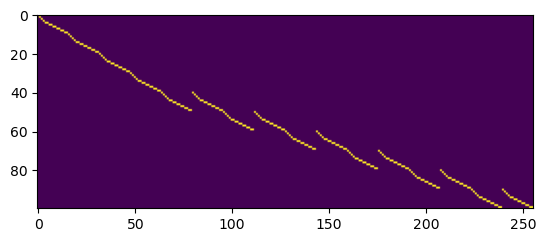

In [246]:
plt.imshow( ~(np.array(UtU) == 0) )

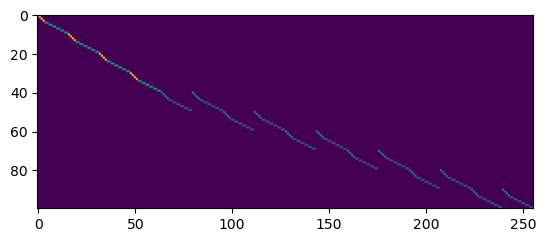

In [248]:
plt.imshow( np.array(UtU) )

In [234]:
vector(np.array(S_ph).reshape(-1)) - VtV  * vector(np.array(S_u).reshape(-1))

(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1/2*(pi_a*s_ac + pi_c*s_ac + pi_g*s_ag + pi_t*s_at + pi_g*s_cg + pi_t*s_ct)/(pi_a*pi_c), 1/2*(pi_a*s_ac + pi_c*s_ac + pi_g*s_ag + pi_t*s_at + pi_g*s_cg + pi_t*s_ct)/(pi_a*pi_c), 1/2*s_cg/pi_a, -1/2*s_cg/pi_a, 1/2*s_ct/pi_a, -1/2*s_ct/pi_a, -1/2*s_ag/pi_c, 1/2*s_ag/pi_c, -1/2*s_at/pi_c, 1/2*s_at/pi_c, 0, 0, 0, 0, 0, 0, 1/2*(pi_a*s_ac + pi_c*s_ac + pi_g*s_ag + pi_t*s_at + pi_g*s_cg + pi_t*s_ct)/(pi_a*pi_c), -1/2*(pi_a*s_ac + pi_c*s_ac + pi_g*s_ag + pi_t*s_at + pi_g*s_cg + pi_t*s_ct)/(pi_a*pi_c), -1/2*s_cg/pi_a, 1/2*s_cg/pi_a, -1/2*s_ct/pi_a, 1/2*s_ct/pi_a, 1/2*s_ag/pi_c, -1/2*s_ag/pi_c, 1/2*s_at/pi_c, -1/2*s_at/pi_c, 0, 0, 0, 0, 0, 0, 1/2*s_cg/pi_a, -1/2*s_cg/pi_a, -1/2*(pi_c*s_ac + pi_a*s_ag + pi_g*s_ag + pi_t*s_at + pi_c*s_cg + pi_t*s_gt)/(pi_a*pi_g), 1/2*(pi_c*s_ac + pi_a*s_ag + pi_g*s_ag + pi_t*s_at + pi_c*s_cg + pi_t*s_gt)/(pi_a*pi_g), 1/2*s_gt/pi_a, -1/2*s_gt/pi_a, 1/2*s_ac/pi_g, -1/2*s_ac/pi_g, 0, 0, -1/2*s_at/pi_g, 1/2*s_at/pi_g, 0, 0, 0, 0, -1/2*s_cg/pi_a, 1/2*s_cg/pi_a, 1/2*(pi_c*s_ac + pi_a*s_ag + pi_g*s_ag + pi_t*s_at + pi_c*s_cg + pi_t*s_gt)/(pi_a*pi_g), -1/2*(pi_c*s_ac + pi_a*s_ag + pi_g*s_ag + pi_t*s_at + pi_c*s_cg + pi_t*s_gt)/(pi_a*pi_g), -1/2*s_gt/pi_a, 1/2*s_gt/pi_a, -1/2*s_ac/pi_g, 1/2*s_ac/pi_g, 0, 0, 1/2*s_at/pi_g, -1/2*s_at/pi_g, 0, 0, 0, 0, 1/2*s_ct/pi_a, -1/2*s_ct/pi_a, 1/2*s_gt/pi_a, -1/2*s_gt/pi_a, -1/2*(pi_c*s_ac + pi_g*s_ag + pi_a*s_at + pi_t*s_at + pi_c*s_ct + pi_g*s_gt)/(pi_a*pi_t), 1/2*(pi_c*s_ac + pi_g*s_ag + pi_a*s_at + pi_t*s_at + pi_c*s_ct + pi_g*s_gt)/(pi_a*pi_t), 0, 0, 1/2*s_ac/pi_t, -1/2*s_ac/pi_t, 1/2*s_ag/pi_t, -1/2*s_ag/pi_t, 0, 0, 0, 0, -1/2*s_ct/pi_a, 1/2*s_ct/pi_a, -1/2*s_gt/pi_a, 1/2*s_gt/pi_a, 1/2*(pi_c*s_ac + pi_g*s_ag + pi_a*s_at + pi_t*s_at + pi_c*s_ct + pi_g*s_gt)/(pi_a*pi_t), -1/2*(pi_c*s_ac + pi_g*s_ag + pi_a*s_at + pi_t*s_at + pi_c*s_ct + pi_g*s_gt)/(pi_a*pi_t), 0, 0, -1/2*s_ac/pi_t, 1/2*s_ac/pi_t, -1/2*s_ag/pi_t, 1/2*s_ag/pi_t, 0, 0, 0, 0, -1/2*s_ag/pi_c, 1/2*s_ag/pi_c, 1/2*s_ac/pi_g, -1/2*s_ac/pi_g, 0, 0, -1/2*(pi_a*s_ac + pi_a*s_ag + pi_c*s_cg + pi_g*s_cg + pi_t*s_ct + pi_t*s_gt)/(pi_c*pi_g), 1/2*(pi_a*s_ac + pi_a*s_ag + pi_c*s_cg + pi_g*s_cg + pi_t*s_ct + pi_t*s_gt)/(pi_c*pi_g), 1/2*s_gt/pi_c, -1/2*s_gt/pi_c, -1/2*s_ct/pi_g, 1/2*s_ct/pi_g, 0, 0, 0, 0, 1/2*s_ag/pi_c, -1/2*s_ag/pi_c, -1/2*s_ac/pi_g, 1/2*s_ac/pi_g, 0, 0, 1/2*(pi_a*s_ac + pi_a*s_ag + pi_c*s_cg + pi_g*s_cg + pi_t*s_ct + pi_t*s_gt)/(pi_c*pi_g), -1/2*(pi_a*s_ac + pi_a*s_ag + pi_c*s_cg + pi_g*s_cg + pi_t*s_ct + pi_t*s_gt)/(pi_c*pi_g), -1/2*s_gt/pi_c, 1/2*s_gt/pi_c, 1/2*s_ct/pi_g, -1/2*s_ct/pi_g, 0, 0, 0, 0, -1/2*s_at/pi_c, 1/2*s_at/pi_c, 0, 0, 1/2*s_ac/pi_t, -1/2*s_ac/pi_t, 1/2*s_gt/pi_c, -1/2*s_gt/pi_c, -1/2*(pi_a*s_ac + pi_a*s_at + pi_g*s_cg + pi_c*s_ct + pi_t*s_ct + pi_g*s_gt)/(pi_c*pi_t), 1/2*(pi_a*s_ac + pi_a*s_at + pi_g*s_cg + pi_c*s_ct + pi_t*s_ct + pi_g*s_gt)/(pi_c*pi_t), 1/2*s_cg/pi_t, -1/2*s_cg/pi_t, 0, 0, 0, 0, 1/2*s_at/pi_c, -1/2*s_at/pi_c, 0, 0, -1/2*s_ac/pi_t, 1/2*s_ac/pi_t, -1/2*s_gt/pi_c, 1/2*s_gt/pi_c, 1/2*(pi_a*s_ac + pi_a*s_at + pi_g*s_cg + pi_c*s_ct + pi_t*s_ct + pi_g*s_gt)/(pi_c*pi_t), -1/2*(pi_a*s_ac + pi_a*s_at + pi_g*s_cg + pi_c*s_ct + pi_t*s_ct + pi_g*s_gt)/(pi_c*pi_t), -1/2*s_cg/pi_t, 1/2*s_cg/pi_t, 0, 0, 0, 0, 0, 0, -1/2*s_at/pi_g, 1/2*s_at/pi_g, 1/2*s_ag/pi_t, -1/2*s_ag/pi_t, -1/2*s_ct/pi_g, 1/2*s_ct/pi_g, 1/2*s_cg/pi_t, -1/2*s_cg/pi_t, -1/2*(pi_a*s_ag + pi_a*s_at + pi_c*s_cg + pi_c*s_ct + pi_g*s_gt + pi_t*s_gt)/(pi_g*pi_t), 1/2*(pi_a*s_ag + pi_a*s_at + pi_c*s_cg + pi_c*s_ct + pi_g*s_gt + pi_t*s_gt)/(pi_g*pi_t), 0, 0, 0, 0, 0, 0, 1/2*s_at/pi_g, -1/2*s_at/pi_g, -1/2*s_ag/pi_t, 1/2*s_ag/pi_t, 1/2*s_ct/pi_g, -1/2*s_ct/pi_g, -1/2*s_cg/pi_t, 1/2*s_cg/pi_t, 1/2*(pi_a*s_ag + pi_a*s_at + pi_c*s_cg + pi_c*s_ct + pi_g*s_gt + pi_t*s_gt)/(pi_g*pi_t), -1/2*(pi_a*s_ag + pi_a*s_at + pi_c*s_cg + pi_

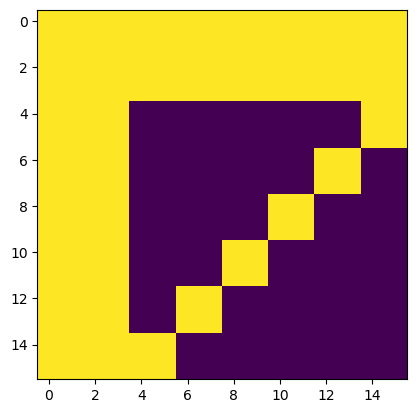

In [243]:
difference = S_ph - V*S_u*V.T
M = np.zeros((difference.nrows(), difference.ncols()), dtype=bool)
for row in range(difference.nrows()):
    for col in range(difference.ncols()):
        M[row,col] = (difference[row,col] == 0)
plt.imshow(M)

In [255]:
for row in vector(map(lambda x: x.expand(), np.sum( V*S_u*V.T * matrix(np.diag([ p for p in pi16_4s])), axis=1))):
    print(row)

-pi_c*s_ac + pi_c^2*s_ac/pi_a + pi_c*pi_g*s_ag/pi_a - 2*pi_g*s_ag + pi_c*pi_t*s_ag/pi_a + pi_c*pi_g*s_at/pi_a + pi_g*s_at - 2*pi_t*s_at
pi_a*s_ac - 2*pi_a^2*s_ac/pi_c + pi_c*s_ac - 2*pi_a*pi_g*s_cg/pi_c + pi_g^2*s_cg/pi_c + pi_g*pi_t*s_cg/pi_c - pi_a*pi_t*s_ct/pi_c + pi_t*s_ct
pi_c*s_ag - 2*pi_a^2*s_ag/pi_g + pi_c*pi_t*s_ag/pi_g - 2*pi_a*pi_c*s_cg/pi_g + pi_g*s_cg + pi_t*s_cg - 2*pi_a*pi_t*s_gt/pi_g + pi_t*s_gt + pi_t^2*s_gt/pi_g
-2*pi_a^2*s_at/pi_t + pi_a*pi_g*s_at/pi_t + pi_c*pi_g*s_at/pi_t + pi_a*s_ct + pi_c*s_ct - 2*pi_a*pi_c*s_ct/pi_t + pi_g*s_gt - 2*pi_a*pi_g*s_gt/pi_t + pi_t*s_gt
3/2*pi_a*s_ac - pi_c*s_ac - 1/2*pi_c^2*s_ac/pi_a - 1/2*pi_c*pi_g*s_ag/pi_a - 1/2*pi_g*s_ag + 1/2*pi_g^2*s_ag/pi_c + 1/2*pi_g*pi_t*s_ag/pi_c + 1/2*pi_a*pi_t*s_at/pi_c - 1/2*pi_c*pi_t*s_at/pi_a - 1/2*pi_g*s_cg + 1/2*pi_c*pi_t*s_cg/pi_a + 1/2*pi_c*pi_g*s_ct/pi_a + 1/2*pi_g*s_ct - 1/2*pi_c*pi_t*s_ct/pi_a - 1/2*pi_t*s_ct
3/2*pi_a*s_ac - pi_c*s_ac - 1/2*pi_c^2*s_ac/pi_a - 1/2*pi_c*pi_g*s_ag/pi_a - 1/2*pi_g*s_

In [268]:
vector(map(lambda x: x.expand().simplify(), np.sum(S_u * matrix(np.diag([ p for p in pi10_4s])), axis=1)))

(0, 0, 0, 0, 0, 0, 0, 0, 0, 0)

In [271]:
vector(map(lambda x: x.expand().simplify(), np.sum(S_ph * matrix(np.diag([ p for p in pi16_4s * perm])), axis=1)))

(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)

In [295]:
Q_u = S_u * matrix(np.diag([ p for p in pi10_4s]))
Q_ph= S_ph * matrix(np.diag([ p for p in pi16_4s * perm]))

Q_u == U * Q_ph * V

True

In [296]:
vector( np.sum(V * Q_u * U, axis=1) )

(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)

In [301]:
Q_lift = V * Q_u * U
for row_idx in range(Q_lift.nrows()):
    for col_idx in range(Q_lift.ncols()):
        if row_idx != col_idx:
            print(row_idx, col_idx, Q_lift[row_idx,col_idx])
        else:
            print(row_idx, col_idx, 'diagonal')
    print()

0 0 diagonal
0 1 0
0 2 0
0 3 0
0 4 pi_c*s_ac
0 5 pi_c*s_ac
0 6 pi_g*s_ag
0 7 pi_g*s_ag
0 8 pi_t*s_at
0 9 pi_t*s_at
0 10 0
0 11 0
0 12 0
0 13 0
0 14 0
0 15 0

1 0 0
1 1 diagonal
1 2 0
1 3 0
1 4 pi_a*s_ac
1 5 pi_a*s_ac
1 6 0
1 7 0
1 8 0
1 9 0
1 10 pi_g*s_cg
1 11 pi_g*s_cg
1 12 pi_t*s_ct
1 13 pi_t*s_ct
1 14 0
1 15 0

2 0 0
2 1 0
2 2 diagonal
2 3 0
2 4 0
2 5 0
2 6 pi_a*s_ag
2 7 pi_a*s_ag
2 8 0
2 9 0
2 10 pi_c*s_cg
2 11 pi_c*s_cg
2 12 0
2 13 0
2 14 pi_t*s_gt
2 15 pi_t*s_gt

3 0 0
3 1 0
3 2 0
3 3 diagonal
3 4 0
3 5 0
3 6 0
3 7 0
3 8 pi_a*s_at
3 9 pi_a*s_at
3 10 0
3 11 0
3 12 pi_c*s_ct
3 13 pi_c*s_ct
3 14 pi_g*s_gt
3 15 pi_g*s_gt

4 0 pi_a*s_ac
4 1 pi_c*s_ac
4 2 0
4 3 0
4 4 diagonal
4 5 -1/2*pi_a*s_ac - 1/2*pi_c*s_ac - 1/2*pi_g*s_ag - 1/2*pi_t*s_at - 1/2*pi_g*s_cg - 1/2*pi_t*s_ct
4 6 1/2*pi_g*s_cg
4 7 1/2*pi_g*s_cg
4 8 1/2*pi_t*s_ct
4 9 1/2*pi_t*s_ct
4 10 1/2*pi_g*s_ag
4 11 1/2*pi_g*s_ag
4 12 1/2*pi_t*s_at
4 13 1/2*pi_t*s_at
4 14 0
4 15 0

5 0 pi_a*s_ac
5 1 pi_c*s_ac
5 2 0
5 3 0
5 4 -1/2*pi_a

In [285]:
%display plain
(V * Q_u * U - Q_ph)[0:4]

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

In [286]:
(V * Q_u * U - Q_ph)[:,0:4]

[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]

In [292]:
(V * Q_u * U - Q_ph)[4:,4:]

[ 1/2*pi_a*s_ac + 1/2*pi_c*s_ac + 1/2*pi_g*s_ag + 1/2*pi_t*s_at + 1/2*pi_g*s_cg + 1/2*pi_t*s_ct -1/2*pi_a*s_ac - 1/2*pi_c*s_ac - 1/2*pi_g*s_ag - 1/2*pi_t*s_at - 1/2*pi_g*s_cg - 1/2*pi_t*s_ct                                                                                 -1/2*pi_g*s_cg                                                                                  1/2*pi_g*s_cg                                                                                 -1/2*pi_t*s_ct                                                                                  1/2*pi_t*s_ct                                                                                  1/2*pi_g*s_ag                                                                                 -1/2*pi_g*s_ag                                                                                  1/2*pi_t*s_at                                                                                 -1/2*pi_t*s_at                                                  

In [166]:
%display latex

without_diagonal( V * S_u * V.T  )

[                                                                                       0                                                                                        0                                                                                        0                                                                                        0                                                                                s_ac/pi_a                                                                                s_ac/pi_a                                                                                s_ag/pi_a                                                                                s_ag/pi_a                                                                                s_at/pi_a                                                                                s_at/pi_a                                                                                        0                                                                                        0                                                                                        0                                                                                        0                                                                                        0                                                                                        0]
[                                                                                       0                                                                                        0                                                                                        0                                                                                        0                                                                                s_ac/pi_c                                                                                s_ac/pi_c                                                                                        0                                                                                        0                                                                                        0                                                                                        0                                                                                s_cg/pi_c                                                                                s_cg/pi_c                                                                                s_ct/pi_c                                                                                s_ct/pi_c                                                                                        0                                                                                        0]
[                                                                                       0                                                                                        0                                                                                        0                                                                                        0                                                                                        0                                                                                        0                                                                                s_ag/pi_g                                                                                s_ag/pi_g                                                                                        0                                                                                        0                                                                                s_cg/pi_g                                                                                s_cg/pi_g                                                                                

In [202]:
guess = (V* S_u * V.T) -  S_ph

In [203]:
guess[0:4,0:4]

[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]

In [204]:
guess[4:,0:4]

[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]

In [205]:
guess[0:4,4:]

[0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0]

In [206]:
%display latex
guess[4:,4:]

[ 1/2*(pi_a*s_ac + pi_c*s_ac + pi_g*s_ag + pi_t*s_at + pi_g*s_cg + pi_t*s_ct)/(pi_a*pi_c) -1/2*(pi_a*s_ac + pi_c*s_ac + pi_g*s_ag + pi_t*s_at + pi_g*s_cg + pi_t*s_ct)/(pi_a*pi_c)                                                                           -1/2*s_cg/pi_a                                                                            1/2*s_cg/pi_a                                                                           -1/2*s_ct/pi_a                                                                            1/2*s_ct/pi_a                                                                            1/2*s_ag/pi_c                                                                           -1/2*s_ag/pi_c                                                                            1/2*s_at/pi_c                                                                           -1/2*s_at/pi_c                                                                                        0                                                                                        0]
[-1/2*(pi_a*s_ac + pi_c*s_ac + pi_g*s_ag + pi_t*s_at + pi_g*s_cg + pi_t*s_ct)/(pi_a*pi_c)  1/2*(pi_a*s_ac + pi_c*s_ac + pi_g*s_ag + pi_t*s_at + pi_g*s_cg + pi_t*s_ct)/(pi_a*pi_c)                                                                            1/2*s_cg/pi_a                                                                           -1/2*s_cg/pi_a                                                                            1/2*s_ct/pi_a                                                                           -1/2*s_ct/pi_a                                                                           -1/2*s_ag/pi_c                                                                            1/2*s_ag/pi_c                                                                           -1/2*s_at/pi_c                                                                            1/2*s_at/pi_c                                                                                        0                                                                                        0]
[                                                                          -1/2*s_cg/pi_a                                                                            1/2*s_cg/pi_a  1/2*(pi_c*s_ac + pi_a*s_ag + pi_g*s_ag + pi_t*s_at + pi_c*s_cg + pi_t*s_gt)/(pi_a*pi_g) -1/2*(pi_c*s_ac + pi_a*s_ag + pi_g*s_ag + pi_t*s_at + pi_c*s_cg + pi_t*s_gt)/(pi_a*pi_g)                                                                           -1/2*s_gt/pi_a                                                                            1/2*s_gt/pi_a                                                                           -1/2*s_ac/pi_g                                                                            1/2*s_ac/pi_g                                                                                        0                                                                                        0                                                                            1/2*s_at/pi_g                                                                           -1/2*s_at/pi_g]
[                                                                           1/2*s_cg/pi_a                                                                           -1/2*s_cg/pi_a -1/2*(pi_c*s_ac + pi_a*s_ag + pi_g*s_ag + pi_t*s_at + pi_c*s_cg + pi_t*s_gt)/(pi_a*pi_g)  1/2*(pi_c*s_ac + pi_a*s_ag + pi_g*s_ag + pi_t*s_at + pi_c*s_cg + pi_t*s_gt)/(pi_a*pi_g)                                                                            1/2*s_gt/pi_a                                                                           -1/2*s_gt/pi_a                                                                            1/2*s_ac/pi_g                                                                           -1/2*s_ac/pi_g                                                                              

In [154]:
guess[4:,4:](pi_t=1-pi_a-pi_c-pi_g).expand().simplify_full()

[ 1/2*((pi_a + pi_c)*s_ac + pi_g*s_ag - (pi_a + pi_c + pi_g - 1)*s_at + pi_g*s_cg - (pi_a + pi_c + pi_g - 1)*s_ct)/(pi_a*pi_c) -1/2*((pi_a + pi_c)*s_ac + pi_g*s_ag - (pi_a + pi_c + pi_g - 1)*s_at + pi_g*s_cg - (pi_a + pi_c + pi_g - 1)*s_ct)/(pi_a*pi_c)                                                                                                                -1/2*s_cg/pi_a                                                                                                                 1/2*s_cg/pi_a                                                                                                                -1/2*s_ct/pi_a                                                                                                                 1/2*s_ct/pi_a                                                                                                                 1/2*s_ag/pi_c                                                                                                                -1/2*s

# GTRxGTR

In [ ]:
pi_a_m, pi_c_m, pi_g_m, pi_t_m = var('pi_a_m, pi_c_m, pi_g_m, pi_t_m')
pi4_m = vector([pi_a_m, pi_c_m, pi_g_m, pi_t_m])

for v in pi4_m:
    assume(v,'real')
    assume(0 <= v)
    assume(v <= 1)

pi_a_p, pi_c_p, pi_g_p, pi_t_p = var('pi_a_p, pi_c_p, pi_g_p, pi_t_p')
pi4_p = vector([pi_a_p, pi_c_p, pi_g_p, pi_t_p])

for v in pi4_p:
    assume(v,'real')
    assume(0 <= v)
    assume(v <= 1)


pi16_mp = vector(np.kron(pi4_m,pi4_p))

s_ac_m, s_ag_m, s_at_m, s_cg_m, s_ct_m, s_gt_m = var('s_ac_m, s_ag_m, s_at_m, s_cg_m, s_ct_m, s_gt_m')
s_m = vector([s_ac_m, s_ag_m, s_at_m, s_cg_m, s_ct_m, s_gt_m])

for v in s_m:
    assume(v,'real')
    assume(0 <= v)

s_ac_p, s_ag_p, s_at_p, s_cg_p, s_ct_p, s_gt_p = var('s_ac_p, s_ag_p, s_at_p, s_cg_p, s_ct_p, s_gt_p')
s_p = vector([s_ac_p, s_ag_p, s_at_p, s_cg_p, s_ct_p, s_gt_p])

for v in s_p:
    assume(v,'real')
    assume(0 <= v)


In [ ]:
q_m = np.full((4,4), x) * 0

q_m[np.triu_indices(4)] = [
    0, s_ac_m, s_ag_m, s_at_m, 
            0, s_cg_m, s_ct_m,
                    0, s_gt_m,
                            0]
q_m = (q_m + q_m.T) @ diagonal_matrix(pi4_m)
q_m -= diagonal_matrix(np.sum(q_m, axis=1))

In [ ]:
q_p = np.full((4,4), x) * 0

q_p[np.triu_indices(4)] = [
    0, s_ac_p, s_ag_p, s_at_p, 
            0, s_cg_p, s_ct_p,
                    0, s_gt_p,
                            0]
q_p = (q_p + q_p.T) @ diagonal_matrix(pi4_p)
q_p -= diagonal_matrix(np.sum(q_p, axis=1))

In [ ]:
q_gtrmp = matrix(q_m).tensor_product(identity_matrix(4)) + identity_matrix(4).tensor_product(matrix(q_p))

In [ ]:
(-pi16_mp * vector(q_gtrmp.diagonal())).simplify_full().expand()

In [ ]:
q_sym_gtrmp = np.diag([sqrt(p) for p in pi16_mp]) @ q_gtrmp @ np.diag([sqrt(1/p) for p in pi16_mp])

In [ ]:
q_sym_gtrmp = np.array([ [c.simplify_real() for c in row] for row in q_sym_gtrmp])

In [ ]:
np.all(q_sym_gtrmp - q_sym_gtrmp.T == 0)

#### code generation

In [ ]:
print('np.'+repr(q_sym_gtrmp).replace('sqrt','np.sqrt').replace(')*np.sqrt(','*').replace('object','np.float64'))

# GTRsq

In [ ]:
q_gtrsq = q_gtrmp(
    s_ac_m=s_ac, s_ac_p=s_ac,
    s_ag_m=s_ag, s_ag_p=s_ag,
    s_at_m=s_at, s_at_p=s_at,
    s_cg_m=s_cg, s_cg_p=s_cg,
    s_ct_m=s_ct, s_ct_p=s_ct,
    s_gt_m=s_gt, s_gt_p=s_gt,
    pi_a_m=pi_a, pi_a_p=pi_a,
    pi_c_m=pi_c, pi_c_p=pi_c,
    pi_g_m=pi_g, pi_g_p=pi_g,
    pi_t_m=pi_t, pi_t_p=pi_t,
)

In [ ]:
pi16sq = pi16_mp(
    pi_a_m=pi_a, pi_a_p=pi_a,
    pi_c_m=pi_c, pi_c_p=pi_c,
    pi_g_m=pi_g, pi_g_p=pi_g,
    pi_t_m=pi_t, pi_t_p=pi_t,
)

In [ ]:
(-pi16sq * vector(q_gtrsq.diagonal())).expand()/4

In [ ]:
(-sum(q_gtrsq.diagonal())/8).simplify_full()

In [ ]:
q_sym_gtrsq = np.diag([sqrt(p) for p in pi16sq]) @ q_gtrsq @ np.diag([sqrt(1/p) for p in pi16sq])

In [ ]:
q_sym_gtrsq = np.array([ [c.simplify_real() for c in row] for row in q_sym_gtrsq])

In [ ]:
np.all(q_sym_gtrsq - q_sym_gtrsq.T == 0)

#### code generation

In [ ]:
print('np.'+repr(q_sym_gtrsq).replace('sqrt','np.sqrt').replace(')*np.sqrt(','*').replace('object','np.float64'))

# Distance functions

## Haploid

In [ ]:
q_f81 = matrix(q_gtr4)(s_ac=1, s_ag=1, s_at=1, s_cg=1, s_ct=1, s_gt=1)

q_f81

In [ ]:
mu_star = (
    (-pi4s @ np.diag(q_f81))
    - (1-(pi_a+pi_c+pi_g+pi_t))**2
    - 2*(pi_a+pi_c+pi_g+pi_t) + 2
).expand()

mu_star

In [ ]:
t = var('t')
d = var('d')
mu = var('mu')
nu = var('nu')
beta = var('beta')

In [ ]:
P = exp(q_f81 * beta * nu)

In [ ]:
exp_mut_prob = 1 - (
    pi4s * vector(
        [
            P[0,0](pi_t=1-pi_a-pi_c-pi_g).expand(),
            P[1,1](pi_t=1-pi_a-pi_c-pi_g).expand(),
            P[2,2](pi_t=1-pi_a-pi_c-pi_g).expand(),
            P[3,3](pi_a=1-pi_t-pi_c-pi_g).expand(),
        ]
    )
)

exp_mut_prob = (
    exp_mut_prob
    + (mu - mu_star)
    + (mu_star - mu)*exp(-beta*nu)
    + ( (pi_a+pi_c+pi_g+pi_t)-1 )*exp(-beta*nu)
).expand()

exp_mut_prob

In [ ]:
haploid_dist = solve( d == exp_mut_prob, nu)[0](mu=1/beta).simplify_real().rhs()

haploid_dist

In [ ]:
d*(1-d) *diff(haploid_dist,d,1)**2

## Unphased Diploid

In [ ]:
q_unph_f81 = matrix(q_unph)(s_ac=1, s_ag=1, s_at=1, s_cg=1, s_ct=1, s_gt=1)

q_unph_f81

In [ ]:
# brief interlude on simplifying sum(pis)=1

com = vector([1,1,1,1])
v1 = vector([1,0,0,0])
v2 = vector([0,1,0,0])
v3 = vector([0,0,1,0])

v1 = v1 - ((v1*com)/(com*com)) * com
v2 = v2 - ((v2*com)/(com*com)) * com
v3 = v3 - ((v3*com)/(com*com)) * com

v2 = v2 - ((v2*v1)/(v1*v1)) * v1
v3 = v3 - ((v3*v1)/(v1*v1)) * v1

v3 = v3 - ((v3*v2)/(v2*v2)) * v2

c1, c2, c3, c4 = var('c1,c2,c3,c4')

B = matrix( [com, v1, v2, v3] )

pretty_print(B)

pretty_print(B.inverse() * vector([c1,c2,c3,c4]))

pretty_print(B * vector([pi_a,pi_c,pi_g,pi_t]))

In [ ]:
mu_unph_star = (
    (-pi10_4s @ np.diag(q_unph_f81))
).expand()

mu_unph_star = ((mu_unph_star
).expand()(
    pi_a=1/4*c1 + c2,
    pi_c=1/4*c1 - 1/3*c2 + c3,
    pi_g=1/4*c1 - 1/3*c2 - 1/2*c3 + c4,
    pi_t=1/4*c1 - 1/3*c2 - 1/2*c3 - c4,
).expand().simplify()(
    c1=1,
    c2=3/4*pi_a - 1/4*pi_c - 1/4*pi_g - 1/4*pi_t,
    c3=2/3*pi_c - 1/3*pi_g - 1/3*pi_t,
    c4=1/2*pi_g - 1/2*pi_t
).expand().simplify()
 - (pi_a+pi_c+pi_g+pi_t-1) * pi_t
 - (pi_a+pi_c+pi_g+pi_t-1) * pi_a
 - (pi_a+pi_c+pi_g+pi_t-1) * pi_c
 - (pi_a+pi_c+pi_g+pi_t-1) * pi_g
 # - (pi_a+pi_c+pi_g+pi_t-1)
 + 1/2*(pi_a+pi_c+pi_g+pi_t-1)**2
).expand()

mu_unph_star

In [ ]:
# equal to twice the previously found rate
mu_unph_star - 2*mu_star

In [ ]:
P = exp(q_unph_f81 * beta * nu)

In [ ]:
exp_mut_prob = (1 - (pi10_4s @ np.diag(P))).expand().simplify()

In [ ]:
exp_mut_prob = exp_mut_prob(pi_t=1-pi_a-pi_c-pi_g).expand().simplify()

In [ ]:
exp_mut_prob = (
    exp_mut_prob(pi_t=1-pi_a-pi_c-pi_g).expand().simplify()(
        pi_a=1/4*c1 + c2,
        pi_c=1/4*c1 - 1/3*c2 + c3,
        pi_g=1/4*c1 - 1/3*c2 - 1/2*c3 + c4,
        pi_t=1/4*c1 - 1/3*c2 - 1/2*c3 - c4,
    ).expand().simplify()(
        c1=1,
        c2=3/4*pi_a - 1/4*pi_c - 1/4*pi_g - 1/4*pi_t,
        c3=2/3*pi_c - 1/3*pi_g - 1/3*pi_t,
        c4=1/2*pi_g - 1/2*pi_t
    ).expand().simplify()
).expand()

In [ ]:
psum = pi_a+pi_c+pi_g+pi_t

(exp_mut_prob - (
    51/32 * (mu_star**2 - mu**2) * exp(-beta*nu)
    # + 11/8 * (mu_star*psum*(psum-1)) * exp(-beta*nu)
)).expand()(
        pi_a=1/4*c1 + c2,
        pi_c=1/4*c1 - 1/3*c2 + c3,
        pi_g=1/4*c1 - 1/3*c2 - 1/2*c3 + c4,
        pi_t=1/4*c1 - 1/3*c2 - 1/2*c3 - c4,
    ).expand().simplify()(
        c1=1,
        c2=3/4*pi_a - 1/4*pi_c - 1/4*pi_g - 1/4*pi_t,
        c3=2/3*pi_c - 1/3*pi_g - 1/3*pi_t,
        c4=1/2*pi_g - 1/2*pi_t
    ).expand().simplify()

In [ ]:
unphased_diploid_dist_solns = solve(d == exp_mut_prob(pi_a=1/4, pi_c=1/4, pi_g=1/4, pi_t=1/4), nu)

In [ ]:
unphased_diploid_dist_solns[0].rhs().simplify_real()(d=0)

In [ ]:
unphased_diploid_dist_solns[1].rhs().simplify_real()(d=0)

In [ ]:
unphased_diploid_dist = unphased_diploid_dist_solns[0].rhs()

unphased_diploid_dist.simplify_full()

In [ ]:
((1/exp(unphased_diploid_dist * beta))/ ((8*sqrt(36-39*d)-9)/39)).simplify_rational() 

In [ ]:
print((1/exp(unphased_diploid_dist * beta)) == ((8*sqrt(36-39*d)-9)/39))

In [ ]:
log(1/((8*sqrt(36-39*d)-9)/39))/beta == unphased_diploid_dist

In [ ]:
unphased_diploid_dist = log(1/((8*sqrt(36-39*d)-9)/39))/beta

In [ ]:
unphased_diploid_dist

In [ ]:
solve((8*sqrt(36-39*d)-9)/39, d)

In [ ]:
unphased_diploid_dist(beta=1, d=0.89)

In [ ]:
(57/64).n()

In [ ]:
(d*(1-d) * diff(unphased_diploid_dist,d)**2)

In [ ]:
mut_rate(
    pi_a=1/4*c1 + c2,
    pi_c=1/4*c1 - 1/3*c2 + c3,
    pi_g=1/4*c1 - 1/3*c2 - 1/2*c3 + c4,
    pi_t=1/4*c1 - 1/3*c2 - 1/2*c3 - c4,
)(c1=1).expand().simplify()(
    c1=pi_a + pi_c + pi_g + pi_t,
    c2=3/4*pi_a - 1/4*pi_c - 1/4*pi_g - 1/4*pi_t,
    c3=2/3*pi_c - 1/3*pi_g - 1/3*pi_t,
    c4=1/2*pi_g - 1/2*pi_t
).expand().simplify()